In [ ]:
TENSOR FLOW FOR REGRESSION

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Model...

Model Performance on Test Data:
Mean Absolute Error (MAE): 14.76% (Average miss in EPS forecast)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


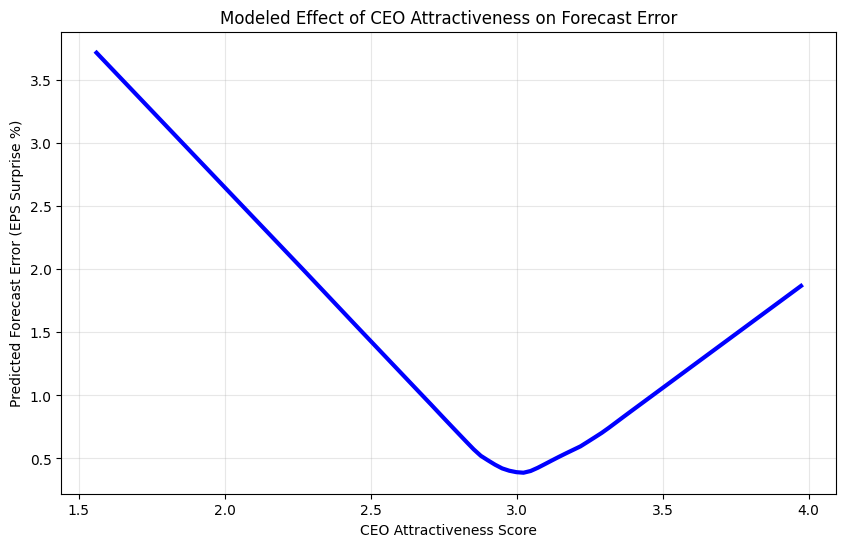

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, mean_absolute_error

# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv('exportv6.csv', sep=';')

# Select relevant features based on your dataset
# We use Attractiveness as the main variable + controls (Gender, Size, etc.)
features = ['CEO Attractiveness Score', 'Squared Term', 'CEO Gender', 'Number of Employees',
             'Market Cap Avg'
            ]

target = 'Forecast Error (EPS Surprise %)'

# Drop rows with missing values (if any) to avoid errors
df_clean = df.dropna(subset=features + [target])

X = df_clean[features].values
y = df_clean[target].values

# 2. PREPROCESSING
# ---------------------------------------------------------
# Neural Networks are very sensitive to scale. We MUST standardize inputs.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. BUILD THE NEURAL NETWORK
# ---------------------------------------------------------
custom_adam = tf.keras.optimizers.Adam(learning_rate=0.001)

model = keras.Sequential([
    # Input Layer & Hidden Layer 1: 64 Neurons, ReLU activation (allows non-linearity)
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2), # Adding dropout helps with the Lift
    # Hidden Layer 2: 32 Neurons, captures deeper patterns
    layers.Dense(32, activation='relu'),

    # Output Layer: 1 Neuron (The predicted Forecast Error)
    # No activation function (linear) because we want a continuous number
    layers.Dense(1)
])

# Optimizer: Adam is standard and efficient
# Loss: MSE (Mean Squared Error) helps minimize the error gap
model.compile(optimizer=custom_adam,
    loss='binary_crossentropy',
    metrics=['accuracy', 'mae',tf.keras.metrics.AUC(name='auc')]
)

# 4. TRAIN THE MODEL
# ---------------------------------------------------------
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
# This will stop the model 15 epochs after the 'U-turn' and jump back to the best version.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,                # Reduce learning rate by 80% (0.0001 -> 0.00002)
    patience=10,                # Do this if no improvement for 5 epochs
    min_lr=1e-6,               # Don't go lower than this
    verbose=1                  # This prints a message so you see it working
)

print("Training Model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # Use part of train data to check overfitting
    epochs=100,           # How many times to loop through the data
    batch_size=32,        # Update weights every 32 rows
    verbose=0             # Set to 1 to see progress bars
)

# 5. EVALUATE PERFORMANCE
# ---------------------------------------------------------
# Unpack all returned values from model.evaluate
loss_val, accuracy_val, mae_val, auc_val = model.evaluate(X_test, y_test, verbose=0)
loss = loss_val
mae = mae_val

print(f"\nModel Performance on Test Data:")
print(f"Mean Absolute Error (MAE): {mae:.2f}% (Average miss in EPS forecast)")

# 6. VISUALIZE THE "ATTRACTIVENESS EFFECT"
# ---------------------------------------------------------
# To see the relationship, we simulate: What if we change ONLY attractiveness?
# We hold all other variables (Size, Gender) at their average values.

# Create a range of attractiveness scores (from min to max in your data)
attr_min, attr_max = df_clean['CEO Attractiveness Score'].min(), df_clean['CEO Attractiveness Score'].max()
test_range = np.linspace(attr_min, attr_max, 100)

# Create a matrix where Attractiveness changes, but others stay constant (at mean)
dummy_data = np.zeros((100, len(features)))
dummy_data[:, 0] = test_range # Set Attractiveness column
# Set other columns to their mean values
for i in range(1, len(features)):
    dummy_data[:, i] = df_clean[features[i]].mean()

# Scale this dummy data using the SAME scaler from before
dummy_scaled = scaler.transform(dummy_data)

# Predict
predictions = model.predict(dummy_scaled)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(test_range, predictions, color='blue', linewidth=3)
plt.title('Modeled Effect of CEO Attractiveness on Forecast Error')
plt.xlabel('CEO Attractiveness Score')
plt.ylabel('Predicted Forecast Error (EPS Surprise %)')
plt.grid(True, alpha=0.3)
plt.show()


--- Further Model Analysis ---


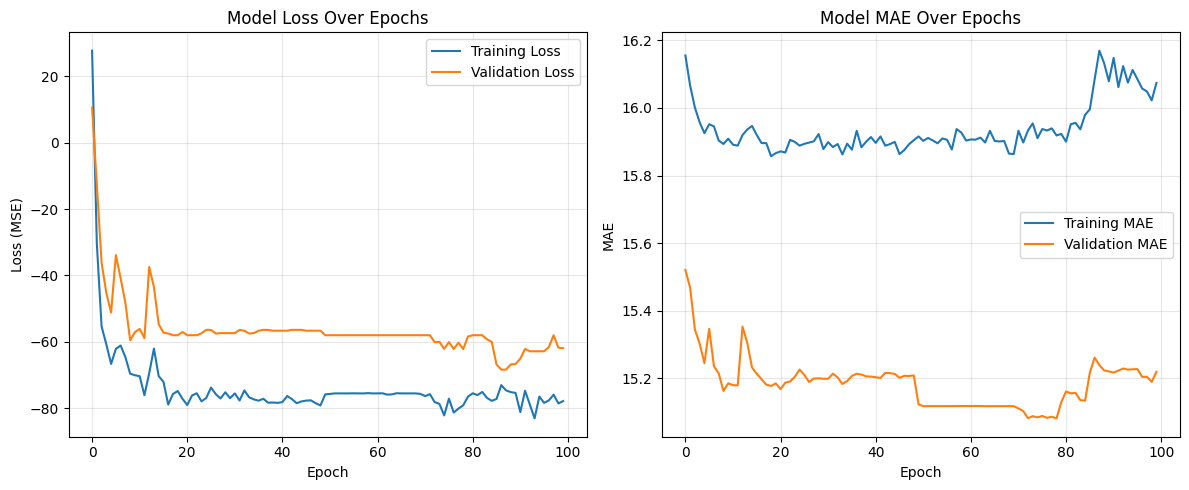

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

R-squared on Test Data: 0.00 (Explains 0% of variance)


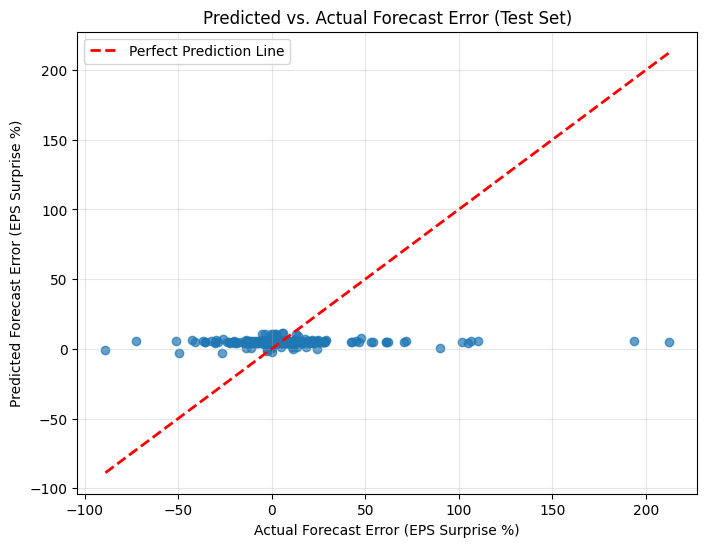

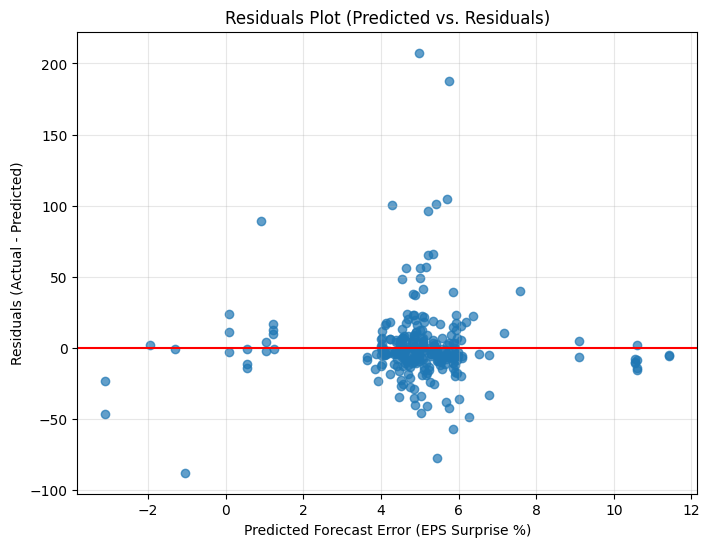

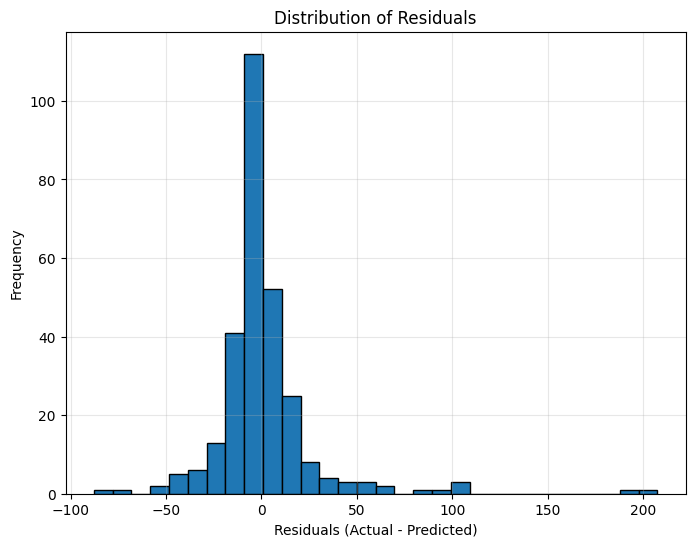

In [ ]:
print("\n--- Further Model Analysis ---")

# 1. Plot Training History
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Calculate R-squared (Coefficient of Determination) on Test Set
# First, make predictions on the test set
y_pred = model.predict(X_test).flatten()

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"\nR-squared on Test Data: {r2:.2f} (Explains {r2*100:.0f}% of variance)")

# 3. Plot Predicted vs. Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2, label='Perfect Prediction Line')
plt.title('Predicted vs. Actual Forecast Error (Test Set)')
plt.xlabel('Actual Forecast Error (EPS Surprise %)')
plt.ylabel('Predicted Forecast Error (EPS Surprise %)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Plot Residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuals Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Forecast Error (EPS Surprise %)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

--- Permutation Feature Importance (based on MAE) ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
  CEO Attractiveness Score: Increase in MAE = 0.0426
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  Squared Term: Increase in MAE = 0.0372
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  CEO Gender: Increase in MAE = 0.0401
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
  Number of Employees: Increase in MAE = 0.0087
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  Market Cap Avg: Increase in MAE = 0.0227

Sorted Feature Importances:
  CEO Attractiveness Score: 0.0426
  CEO Gender: 0.0401
  Squared Term: 0.0372
  Market Cap Avg: 0.0227
  Number of Employees: 0.0087


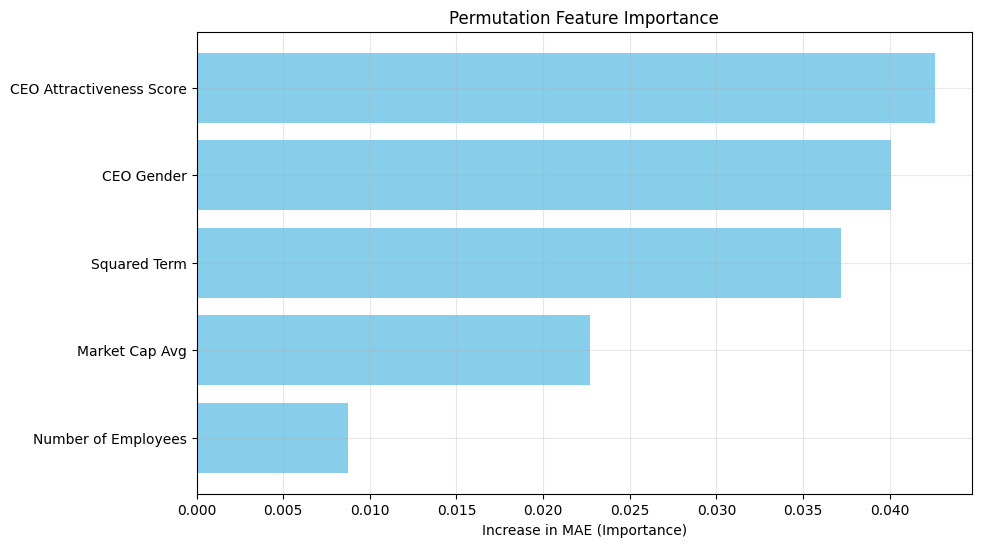

In [ ]:
from sklearn.metrics import mean_absolute_error

# Get the baseline MAE of the trained model on the test set
# (We already calculated `mae` in cell 3AmeDFiDTHMf, but re-calculate for clarity here if needed)
current_mae = mean_absolute_error(y_test, model.predict(X_test).flatten())

feature_importances = {}

print("\n--- Permutation Feature Importance (based on MAE) ---")
for i, feature_name in enumerate(features):
    # Create a copy of the scaled test data
    X_test_shuffled = X_test.copy()

    # Shuffle the values of the current feature
    np.random.shuffle(X_test_shuffled[:, i])

    # Make predictions with the shuffled data
    shuffled_predictions = model.predict(X_test_shuffled).flatten()

    # Calculate MAE with the shuffled feature
    shuffled_mae = mean_absolute_error(y_test, shuffled_predictions)

    # Calculate the importance as the increase in MAE
    importance = shuffled_mae - current_mae
    feature_importances[feature_name] = importance
    print(f"  {feature_name}: Increase in MAE = {importance:.4f}")

# Sort features by importance (highest increase in MAE means more important)
sorted_importances = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

print("\nSorted Feature Importances:")
for feature, importance in sorted_importances:
    print(f"  {feature}: {importance:.4f}")

# Optional: Visualize feature importances
importance_names = [item[0] for item in sorted_importances]
importance_values = [item[1] for item in sorted_importances]

plt.figure(figsize=(10, 6))
plt.barh(importance_names, importance_values, color='skyblue')
plt.xlabel('Increase in MAE (Importance)')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis() # Highest importance at the top
plt.grid(True, alpha=0.3)
plt.show()

2nd version

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score

# 1. Load the 'exportv7.csv' dataset (corrected filename)
df = pd.read_csv('exportv8.csv', sep=';')
print(f"Data Loaded: {df.shape}")

# 2. Define the regression target variable
target = 'Analysts Recommendations'

# 3. Re-create engineered features and update the `all_features` list
# Original features from the classification cell (or generally used as base)
original_features_base = ['CEO Attractiveness Score', 'CEO Gender', 'Log Number of Employees', 'Analysts Recommendations'
                     'Squared Term', 'Log Market Cap', 'Age']

# Create interaction features as seen in the classification cell
df['CEO_x_MarketCap'] = df['CEO Attractiveness Score'] * df['Market Cap Avg']
df['CEO_x_Analysts'] = df['CEO Attractiveness Score'] * df['Analysts Recommendations']
df['Gender_x_Attract'] = df['CEO Gender'] * df['CEO Attractiveness Score']
df['Employees_per_Cap'] = df['Log Number of Employees'] / (df['Log Market Cap'] + 1)
df['CEO_x_Age'] = df['CEO Attractiveness Score'] * df['Age']


# ALL features for modeling (original + engineered)
all_features = [col for col in original_features_base if col in df.columns] # Ensure base features exist

# Add engineered features if they were successfully created
if 'CEO_x_MarketCap' in df.columns: all_features.append('CEO_x_MarketCap')
if 'CEO_x_Analysts' in df.columns: all_features.append('CEO_x_Analysts')
if 'Gender_x_Attract' in df.columns: all_features.append('Gender_x_Attract')
if 'Employees_per_Cap' in df.columns: all_features.append('Employees_per_Cap')
if 'CEO_x_Age' in df.columns: all_features.append('CEO_x_Age')

print(f"Features for regression: {all_features}")

# 4. Drop any rows with missing values in specified columns
df_clean = df.dropna(subset=all_features + [target])
print(f"Shape after dropping NaNs: {df_clean.shape}")

# 5. Separate features (X) and target (y)
X = df_clean[all_features].values
y = df_clean[target].values

# 6. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
target_transformer = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)
y_train_transformed = target_transformer.fit_transform(
    y_train.reshape(-1, 1)
).flatten()
y_test_transformed = target_transformer.transform(
    y_test.reshape(-1, 1)
).flatten()

# 7. Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled using StandardScaler.")



Data Loaded: (1423, 21)
Features for regression: ['CEO Attractiveness Score', 'CEO Gender', 'Log Number of Employees', 'Log Market Cap', 'Age', 'CEO_x_MarketCap', 'CEO_x_Analysts', 'Gender_x_Attract', 'Employees_per_Cap', 'CEO_x_Age']
Shape after dropping NaNs: (1423, 26)
X_train shape: (1138, 10), y_train shape: (1138,)
X_test shape: (285, 10), y_test shape: (285,)
Features scaled using StandardScaler.


In [ ]:
!pip install keras-tuner
print("keras-tuner installed.")
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

# 1. Define a function `build_model` for regression
def build_model(hp):
    model = keras.Sequential()

    # 3. Add hidden layers with tunable units and dropout
    # Tune the number of layers (1 to 3)
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            # Tune number of units separately for each layer
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu',
            # Ensure input shape is defined for the first layer
            input_shape=(X_train_scaled.shape[1],) if i == 0 else None
        ))
        # Tune dropout rate
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    # 4. Add the output layer for regression (1 neuron, linear activation)
    model.add(layers.Dense(1, activation='linear'))

    # 5. Compile the model with Adam optimizer and tunable learning rate
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
       # 6. Set loss to Huber for regression
        loss=tf.keras.losses.Huber(),
        # 7. Set metrics to MAE and MSE for regression
        metrics=['mean_absolute_error', 'mean_squared_error']
    )
    return model

# 8. Instantiate keras_tuner.Hyperband
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective('val_loss', direction='min'), # Objective to minimize validation loss
    max_epochs=20,
    factor=3,
    directory='my_dir_regression',
    project_name='ceo_regression_tuning'
)

# 9. Define an EarlyStopping callback
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)

print("Keras Tuner Hyperband instance for regression created.")
print("Build model function defined for regression with tunable hyperparameters.")

keras-tuner installed.
Reloading Tuner from my_dir_regression/ceo_regression_tuning/tuner0.json
Keras Tuner Hyperband instance for regression created.
Build model function defined for regression with tunable hyperparameters.


In [ ]:
print("\n--- Starting Hyperparameter Search ---")
tuner.search(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=1
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nOptimal number of layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f"Optimal Units (Layer {i}): {best_hps.get(f'units_{i}')}")
    print(f"Optimal Dropout (Layer {i}): {best_hps.get(f'dropout_{i}')}")
print(f"Optimal Learning Rate: {best_hps.get('lr')}")

print("\n--- Training Final Model with Best Hyperparameters ---")
model = tuner.hypermodel.build(best_hps)

# Train the best model found by the tuner
history = model.fit(
    X_train_scaled, y_train,
    epochs=5,  # Using a fixed number of epochs, could also use callbacks like EarlyStopping here
    validation_split=0.2,
    callbacks=[stop_early], # Use the EarlyStopping callback defined earlier
    verbose=1
)

# 7. Evaluate the best model on the test data
loss_test, mae_test, mse_test = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nModel Performance on Test Data:")
print(f"Test Loss (MSE): {loss_test:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"Test Mean Squared Error (MSE): {mse_test:.4f}")


--- Starting Hyperparameter Search ---

Optimal number of layers: 2
Optimal Units (Layer 0): 96
Optimal Dropout (Layer 0): 0.0
Optimal Units (Layer 1): 160
Optimal Dropout (Layer 1): 0.4
Optimal Learning Rate: 0.005143948504561813

--- Training Final Model with Best Hyperparameters ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 16.7438 - mean_absolute_error: 17.2385 - mean_squared_error: 367.9466 - val_loss: 5.0779 - val_mean_absolute_error: 5.5635 - val_mean_squared_error: 55.4986
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.3455 - mean_absolute_error: 5.8285 - mean_squared_error: 58.1697 - val_loss: 2.8294 - val_mean_absolute_error: 3.2997 - val_mean_squared_error: 18.1577
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 2.9431 - mean_absolute_error: 3.4125 - mean_squared_error: 19.4936 - val_loss: 1.3483 - val_mean_absolute_error: 1.7946 - val_mean_squared_error: 4.9148
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.8772 - mean_absolute_error: 2.3368 - mean_squared_error: 8.8654 - val_loss: 0.7638 - val_mean_absolute_error: 1.2018 - val_mean_squared_error: 1.9895
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.6686 - mean_absolute_error: 2.1137 - mean_squared_error: 7.6897 - val_loss: 0.3482 - val_mean_absolute


--- Further Model Analysis ---


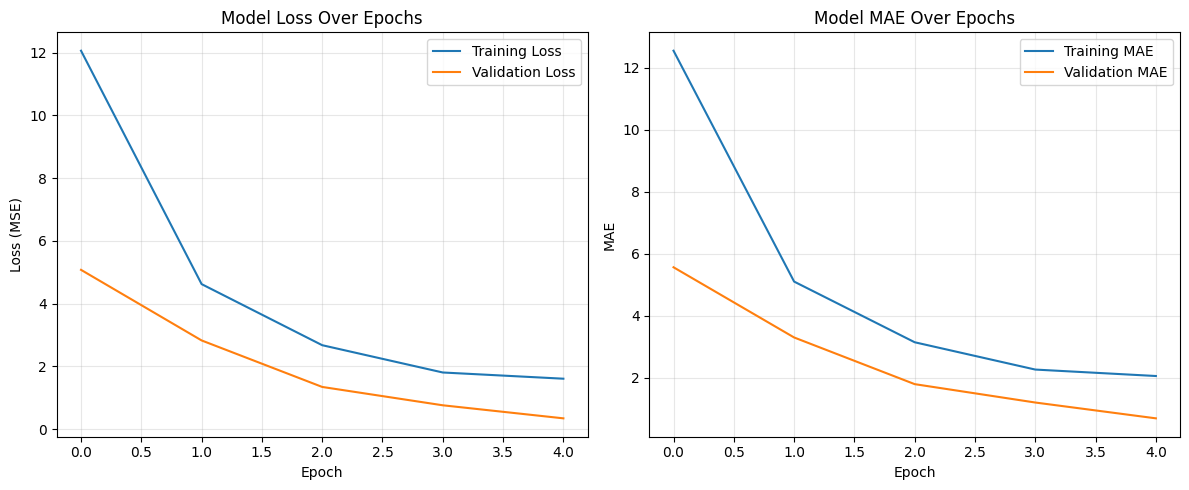

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

R-squared on Test Data: 0.95 (Explains 95% of variance)


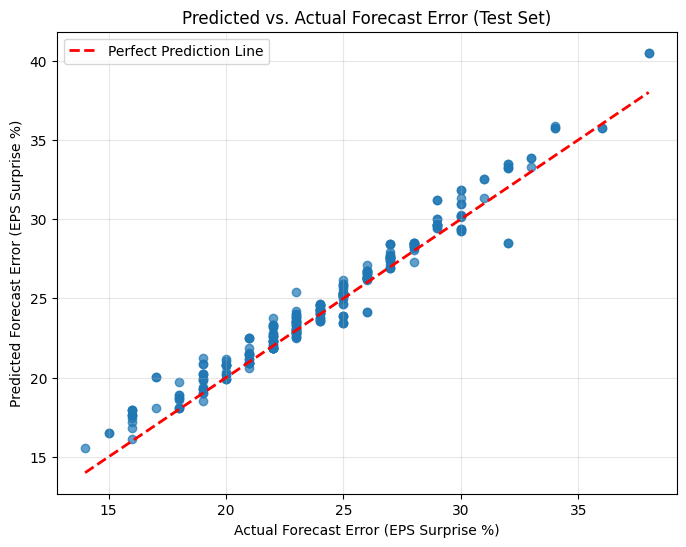

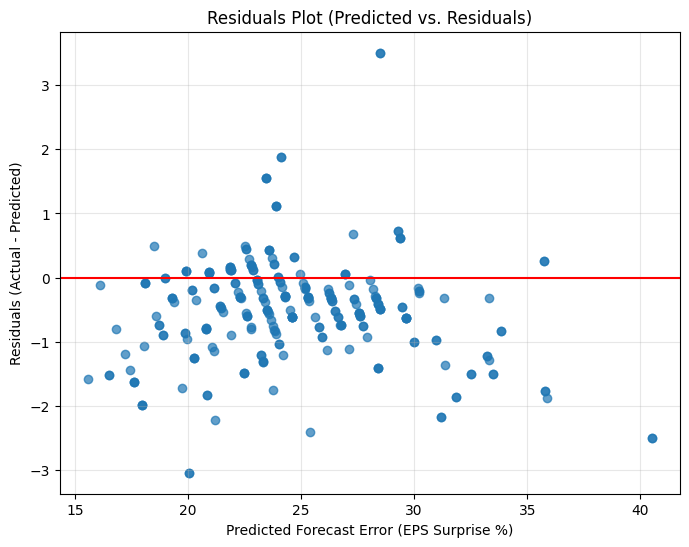

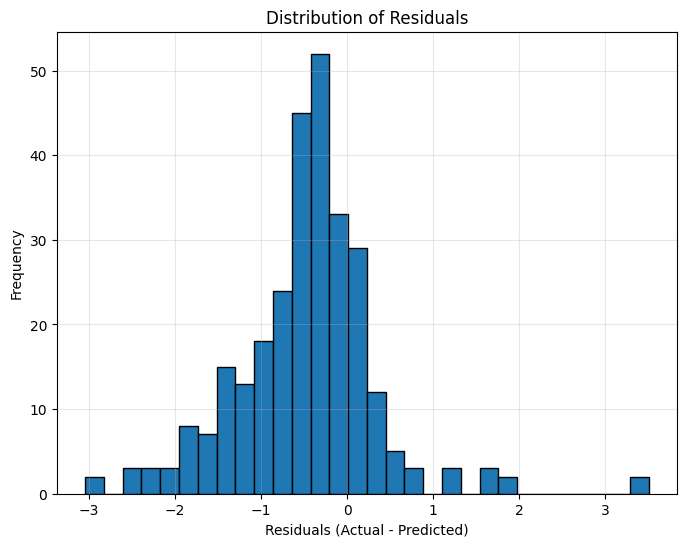

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

print("\n--- Further Model Analysis ---")

# 1. Plot Training History
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Calculate R-squared (Coefficient of Determination) on Test Set
y_pred = model.predict(X_test_scaled).flatten()
r2 = r2_score(y_test, y_pred)
print(f"\nR-squared on Test Data: {r2:.2f} (Explains {r2*100:.0f}% of variance)")

# 3. Plot Predicted vs. Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2, label='Perfect Prediction Line')
plt.title('Predicted vs. Actual Forecast Error (Test Set)')
plt.xlabel('Actual Forecast Error (EPS Surprise %)')
plt.ylabel('Predicted Forecast Error (EPS Surprise %)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Plot Residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuals Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Forecast Error (EPS Surprise %)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


--- Visualizing Modeled Effect of CEO Attractiveness ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


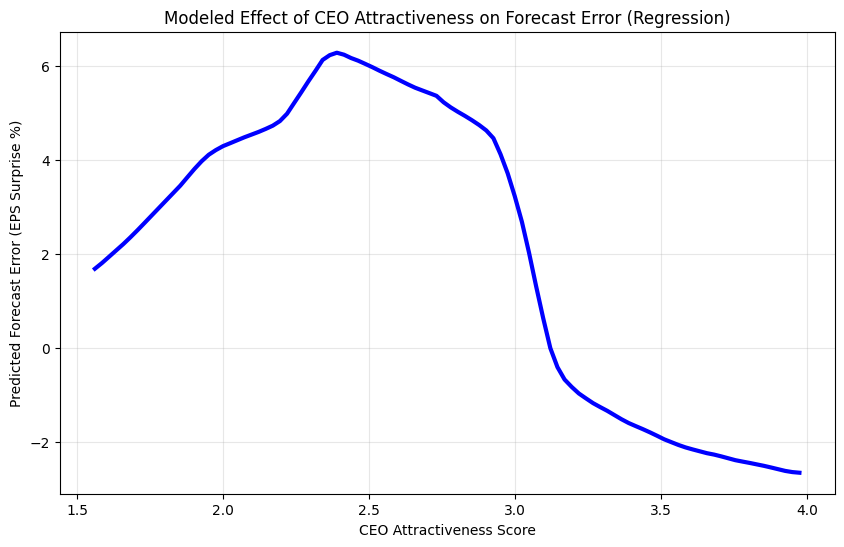

Visualization of CEO Attractiveness effect completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\n--- Visualizing Modeled Effect of CEO Attractiveness ---")

# 1. Get min and max for 'CEO Attractiveness Score' from df_clean
attr_min, attr_max = df_clean['CEO Attractiveness Score'].min(), df_clean['CEO Attractiveness Score'].max()
test_range = np.linspace(attr_min, attr_max, 100)

# 2. Create a new dummy dataset with 100 rows and the same number of features as X
dummy_data = np.zeros((100, len(all_features)))

# 3. For each row, set 'CEO Attractiveness Score' and other features to their means
# Find the index of 'CEO Attractiveness Score' in all_features
attr_idx = all_features.index('CEO Attractiveness Score')
dummy_data[:, attr_idx] = test_range # Set Attractiveness column

# Set other columns to their mean values from df_clean
for i, feature_name in enumerate(all_features):
    if feature_name != 'CEO Attractiveness Score':
        dummy_data[:, i] = df_clean[feature_name].mean()

# 4. Scale this dummy data using the SAME scaler from before
dummy_scaled = scaler.transform(dummy_data)

# 5. Predict using the trained model
predictions = model.predict(dummy_scaled).flatten()

# 6. Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(test_range, predictions, color='blue', linewidth=3)

# 7. Add a title
plt.title('Modeled Effect of CEO Attractiveness on Forecast Error (Regression)')

# 8. Label the x and y axes appropriately
plt.xlabel('CEO Attractiveness Score')
plt.ylabel('Predicted Forecast Error (EPS Surprise %)')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# 9. Display the plot
plt.show()

print("Visualization of CEO Attractiveness effect completed.")


--- Visualizing Modeled Effect of CEO Attractiveness on Analysts Recommendations ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


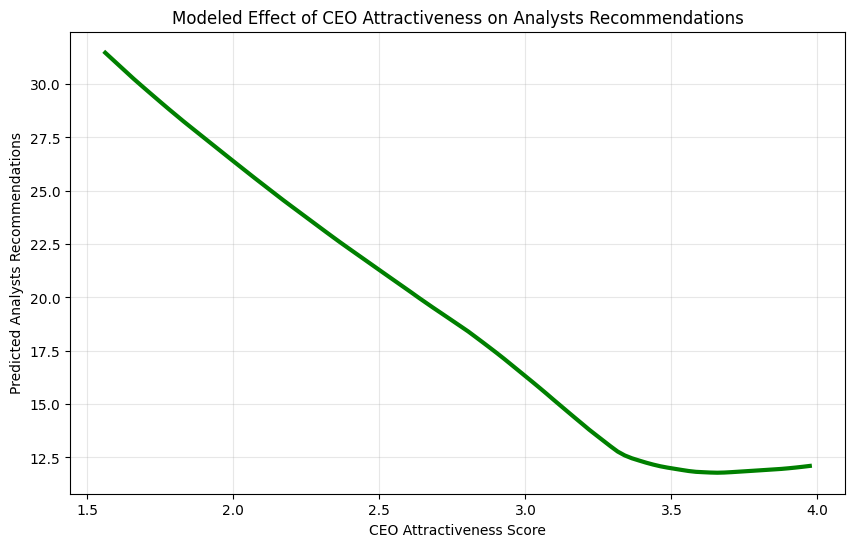

Visualization of CEO Attractiveness effect on Analysts Recommendations completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("\n--- Visualizing Modeled Effect of CEO Attractiveness on Analysts Recommendations ---")

# 1. Get min and max for 'CEO Attractiveness Score' from df_clean
attr_min, attr_max = df_clean['CEO Attractiveness Score'].min(), df_clean['CEO Attractiveness Score'].max()
test_range = np.linspace(attr_min, attr_max, 100)

# 2. Create a new dummy dataset with 100 rows and the same number of features as X
dummy_data = np.zeros((100, len(all_features)))

# 3. For each row, set 'CEO Attractiveness Score' and other features to their means
# Find the index of 'CEO Attractiveness Score' in all_features
attr_idx = all_features.index('CEO Attractiveness Score')
dummy_data[:, attr_idx] = test_range # Set Attractiveness column

# Set other columns to their mean values from df_clean
for i, feature_name in enumerate(all_features):
    if feature_name != 'CEO Attractiveness Score':
        dummy_data[:, i] = df_clean[feature_name].mean()

# 4. Scale this dummy data using the SAME scaler from before
dummy_scaled = scaler.transform(dummy_data)

# 5. Predict using the trained model
predictions = model.predict(dummy_scaled).flatten()

# 6. Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(test_range, predictions, color='green', linewidth=3)

# 7. Add a title
plt.title('Modeled Effect of CEO Attractiveness on Analysts Recommendations')

# 8. Label the x and y axes appropriately
plt.xlabel('CEO Attractiveness Score')
plt.ylabel('Predicted Analysts Recommendations')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# 9. Display the plot
plt.show()

print("Visualization of CEO Attractiveness effect on Analysts Recommendations completed.")

In [ ]:
# extra performance metrics - MAE
import numpy as np
from sklearn.metrics import mean_absolute_error

# Mean baseline (trained only on training data)
mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)

mae_mean = mean_absolute_error(y_test, mean_pred)

print(f"Baseline MAE (mean predictor): {mae_mean:.2f}")

from sklearn.linear_model import LinearRegression

# Linear regression baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, lr_pred)

print(f"Baseline MAE (linear regression): {mae_lr:.2f}")
print(print(f"Test Mean Absolute Error (MAE): {mae_test:.4f}"))

improvement_vs_mean = (mae_mean - mae_test) / mae_mean * 100
improvement_vs_lr = (mae_lr - mae_test) / mae_lr * 100

print(f"\nImprovement vs mean baseline: {improvement_vs_mean:.1f}%")
print(f"Improvement vs linear model : {improvement_vs_lr:.1f}%")



Baseline MAE (mean predictor): 3.43
Baseline MAE (linear regression): 0.36
Test Mean Absolute Error (MAE): 0.7059
None

Improvement vs mean baseline: 79.4%
Improvement vs linear model : -95.8%


In [ ]:
# extra performance metrics - quintile loss
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Access the best_hps (best hyperparameters) from the tuner.
# (best_hps is already available from the previous executed cell)

# 2. Create a tf.keras.Sequential model named model_no_attr.
model_no_attr = keras.Sequential()

# 3. Add a layers.Dense layer as the first hidden layer to model_no_attr.
# It should have units equal to best_hps.get('units_0'), activation='relu',
# and input_shape=(X_train_no_attr.shape[1],).
model_no_attr.add(layers.Dense(
    units=best_hps.get('units_0'),
    activation='relu',
    input_shape=(X_train_no_attr.shape[1],)
))

# 4. Add a tf.keras.layers.Dropout layer to model_no_attr with a dropout rate
# equal to best_hps.get('dropout_0').
model_no_attr.add(layers.Dropout(best_hps.get('dropout_0')))

# For simplicity, assuming the best model had only one hidden layer as in the previous output.
# If best_hps.get('num_layers') > 1, additional loops would be needed here based on the original build_model function.
# Given the executed output showed 'Optimal number of layers: 1', we'll stick to one hidden layer.

# 5. Add a final layers.Dense output layer with units=1 and activation='linear'.
model_no_attr.add(layers.Dense(1, activation='linear'))

# 6. Compile model_no_attr using the tf.keras.optimizers.Adam optimizer
# with learning_rate equal to best_hps.get('lr') and clipnorm=1.0.
# Set the loss to tf.keras.losses.Huber() and metrics to ['mean_absolute_error', 'mean_squared_error'].
learning_rate_no_attr = best_hps.get('lr')
model_no_attr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_no_attr, clipnorm=1.0),
    loss=tf.keras.losses.Huber(),
    metrics=['mean_absolute_error', 'mean_squared_error']
)

print("model_no_attr has been successfully defined and compiled.")

NameError: name 'X_train_no_attr' is not defined

In [ ]:
# extra performance metrics
import numpy as np
import tensorflow as tf
def quantile_loss(y_true, y_pred, tau=0.1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    error = y_true - y_pred
    loss = tf.maximum(tau * error, (tau - 1) * error)
    return np.mean(np.maximum(tau * error, (tau - 1) * error))

tau_downside = 0.10

ql_nn_down = quantile_loss(
    y_test,
    mae_test,
    tau=tau_downside
)

tau_median = 0.50
ql_nn_median = quantile_loss(
    y_test,
    mae_test,
    tau=tau_median
)

mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)
ql_mean_down = quantile_loss(
    y_test,
    mean_pred,
    tau=tau_downside
)


print(f"NN Quantile Loss (τ={tau_downside}): {ql_nn_down:.3f}")
print(f"NN Quantile Loss (τ={tau_median}): {ql_nn_median:.3f}")
print(f"Mean baseline Quantile Loss (τ={tau_downside}): {ql_mean_down:.3f}")

# all_features = list of column names used to build X
ceo_attr_idx = all_features.index("CEO Attractiveness Score")

X_train_no_attr = np.delete(X_train_scaled, ceo_attr_idx, axis=1)
X_test_no_attr  = np.delete(X_test_scaled,  ceo_attr_idx, axis=1)
model_no_attr.fit(X_train_no_attr, y_train_transformed)

pred_no_attr = target_transformer.inverse_transform(
    model_no_attr.predict(X_test_no_attr).reshape(-1, 1)
).flatten()

ql_no_attr = quantile_loss(y_test, pred_no_attr, tau=0.1)
print(f"NN Quantile Loss without CEO attractiveness (τ={tau_downside}): {ql_no_attr:.3f}")

NN Quantile Loss (τ=0.1): 13.230
NN Quantile Loss (τ=0.5): 9.741
Mean baseline Quantile Loss (τ=0.1): 7.386


ValueError: You must call `compile()` before using the model.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

--- Permutation Feature Importance (based on MAE) ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
  CEO Attractiveness Score: Increase in MAE = 3.3926
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  CEO Gender: Increase in MAE = 0.7170
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
  Log Number of Employees: Increase in MAE = 1.7768
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  Log Market Cap: Increase in MAE = 1.3603
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
  Age: Increase in MAE = 1.5804
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
  CEO_x_MarketCap: Increase in MAE = 2.5562
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  CEO_x_Analysts: Increase in MAE = 5.3254
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  Gender_x_Attract: Increase in MAE = 3.6568
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  Employees_per_Cap: Increase in MAE = 1.8568
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  CEO_x_Age: Increase in MAE = 2.7213

Sorted Feature Importances:
  CEO_x_Analysts: 5.3254
  Gender_x_Attract: 3.6568
  CEO Attra

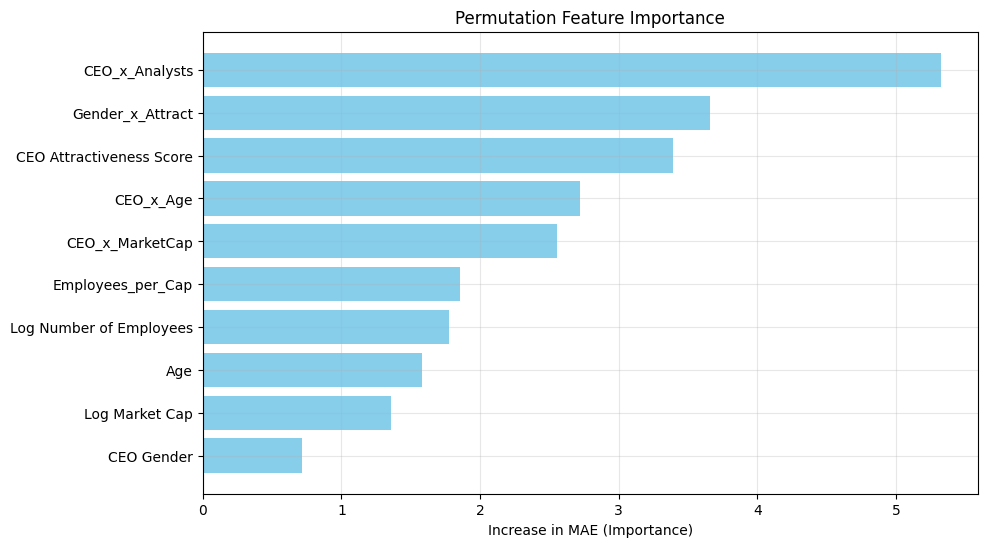

In [ ]:
# FEATURE IMPORTANCE
from sklearn.metrics import mean_absolute_error

# Get the baseline MAE of the trained model on the test set
# (We already calculated `mae` in cell 3AmeDFiDTHMf, but re-calculate for clarity here if needed)
current_mae = mean_absolute_error(y_test, model.predict(X_test_scaled).flatten()) # Use X_test_scaled

feature_importances = {}

print("\n--- Permutation Feature Importance (based on MAE) ---")
for i, feature_name in enumerate(all_features): # Changed 'features' to 'all_features'
    # Create a copy of the scaled test data
    X_test_shuffled = X_test_scaled.copy() # Use X_test_scaled

    # Shuffle the values of the current feature
    np.random.shuffle(X_test_shuffled[:, i])

    # Make predictions with the shuffled data
    shuffled_predictions = model.predict(X_test_shuffled).flatten()

    # Calculate MAE with the shuffled feature
    shuffled_mae = mean_absolute_error(y_test, shuffled_predictions)

    # Calculate the importance as the increase in MAE
    importance = shuffled_mae - current_mae
    feature_importances[feature_name] = importance
    print(f"  {feature_name}: Increase in MAE = {importance:.4f}")

# Sort features by importance (highest increase in MAE means more important)
sorted_importances = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)

print("\nSorted Feature Importances:")
for feature, importance in sorted_importances:
    print(f"  {feature}: {importance:.4f}")

# Optional: Visualize feature importances
importance_names = [item[0] for item in sorted_importances]
importance_values = [item[1] for item in sorted_importances]

plt.figure(figsize=(10, 6))
plt.barh(importance_names, importance_values, color='skyblue')
plt.xlabel('Increase in MAE (Importance)')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis() # Highest importance at the top
plt.grid(True, alpha=0.3)
plt.show()